In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.utils import load_cmapss, add_rul, split_by_engine, get_features_targets 
from sklearn.preprocessing import StandardScaler
df = load_cmapss("../data/raw/train_FD001.txt")
df = add_rul(df, cap=140)

train_df, val_df = split_by_engine(df)

X_train, y_train, X_val, y_val = get_features_targets(train_df, val_df)

# scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


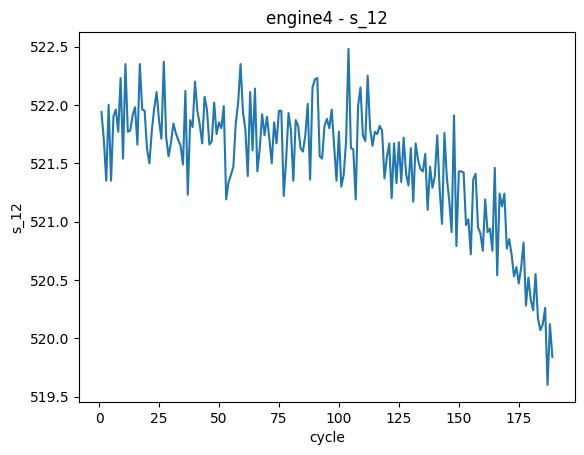

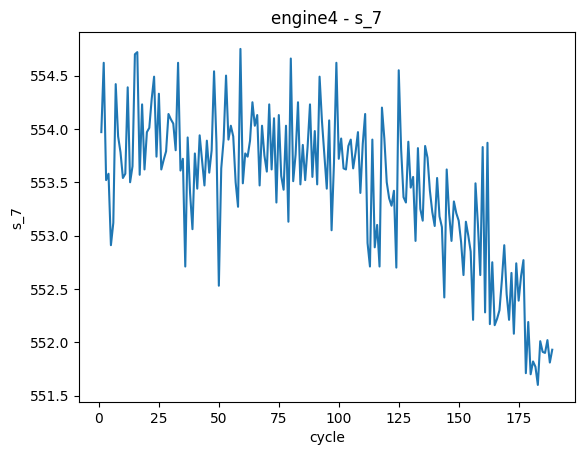

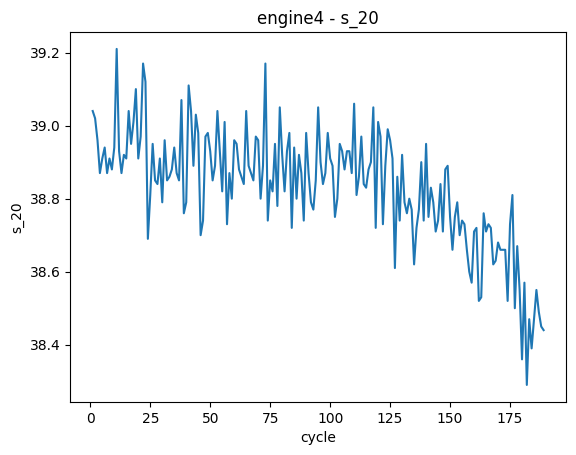

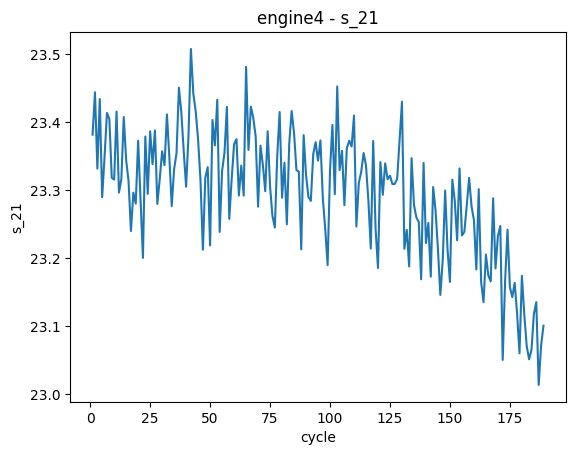

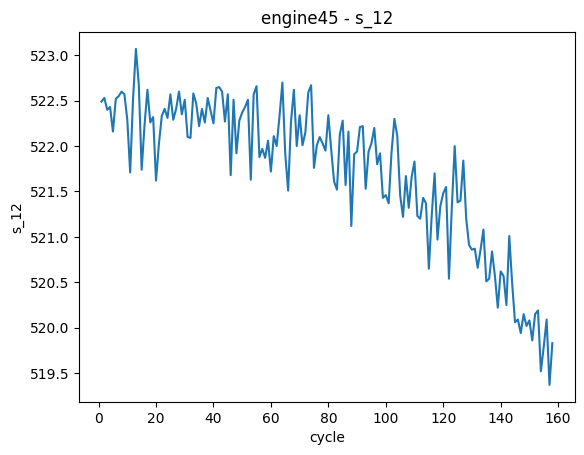

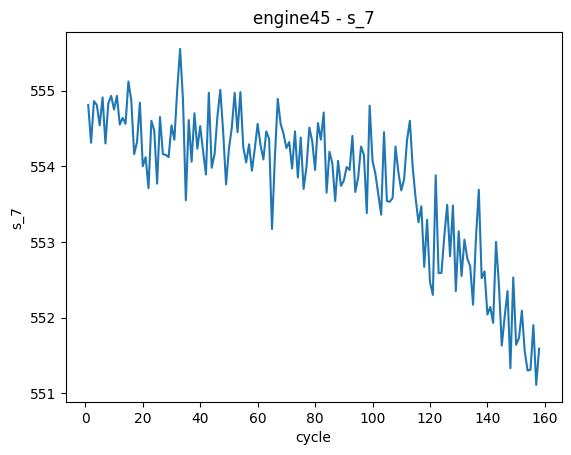

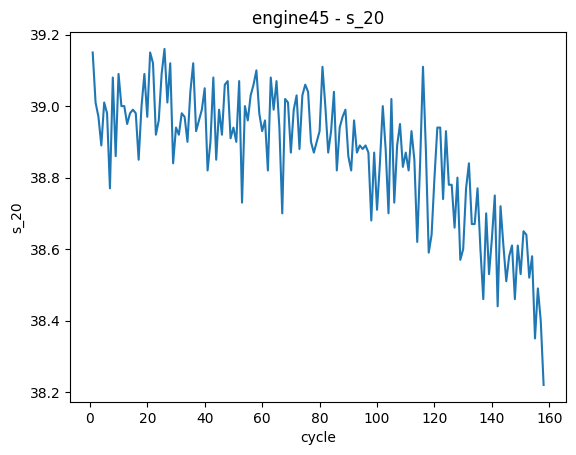

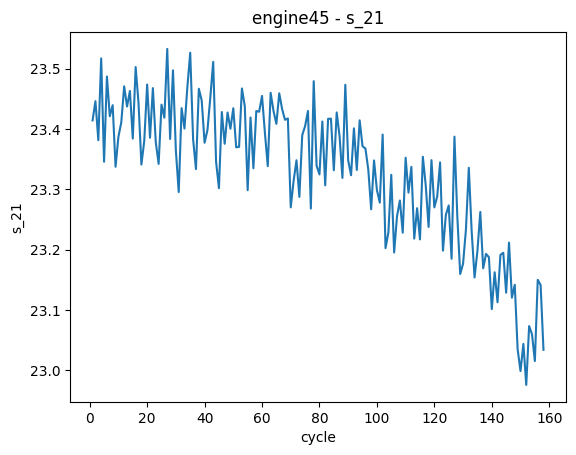

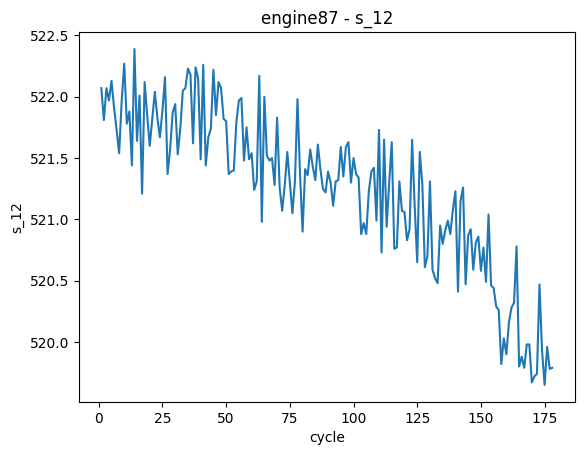

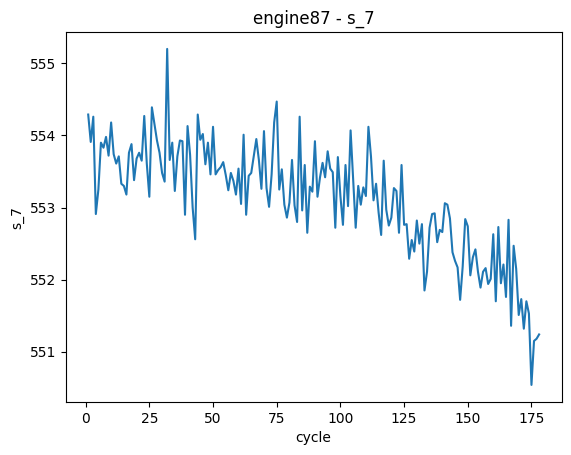

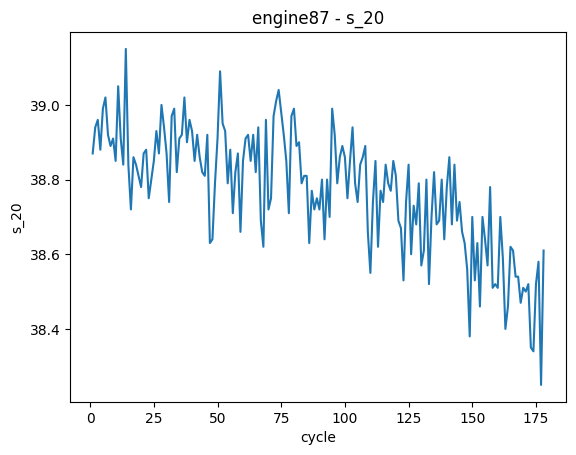

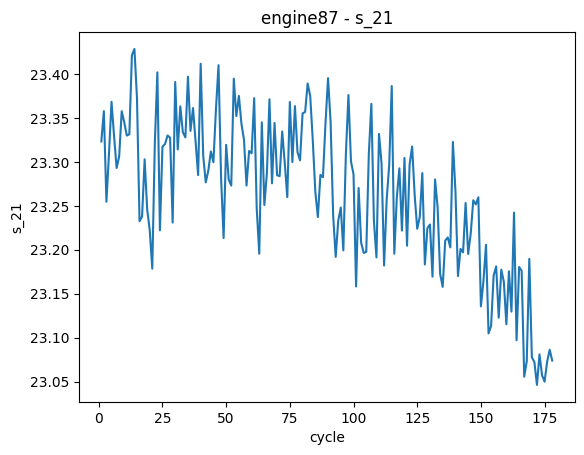

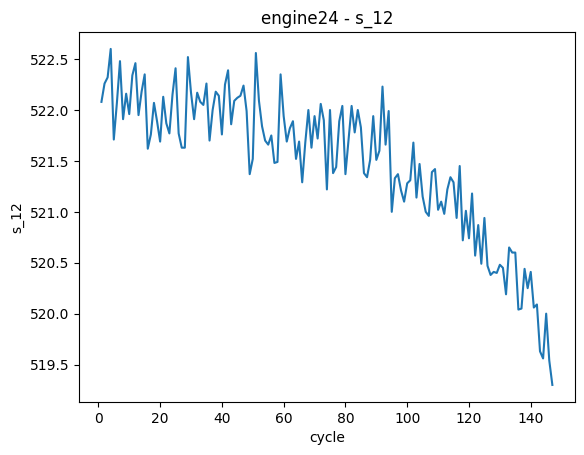

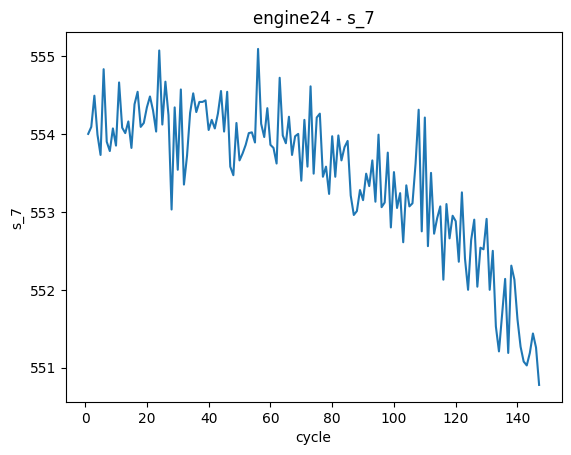

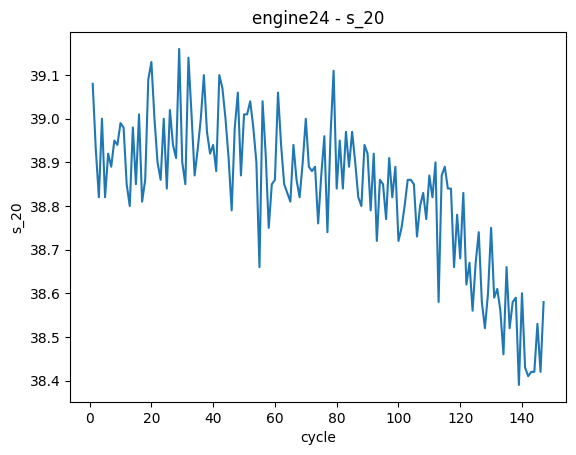

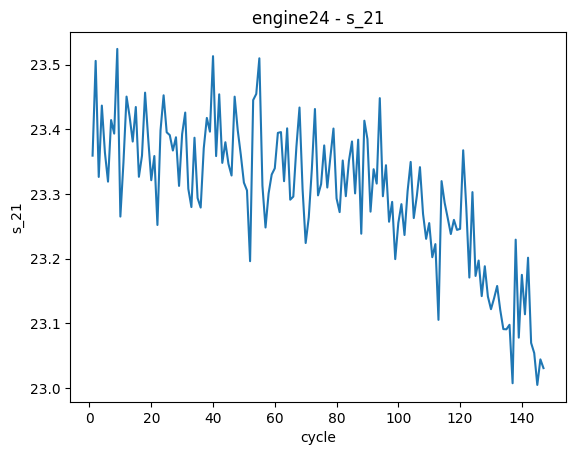

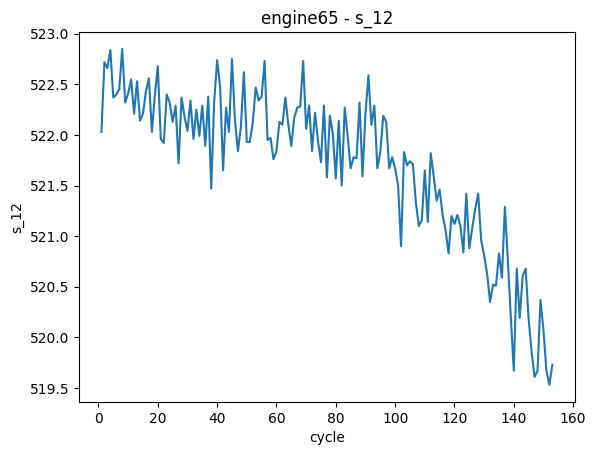

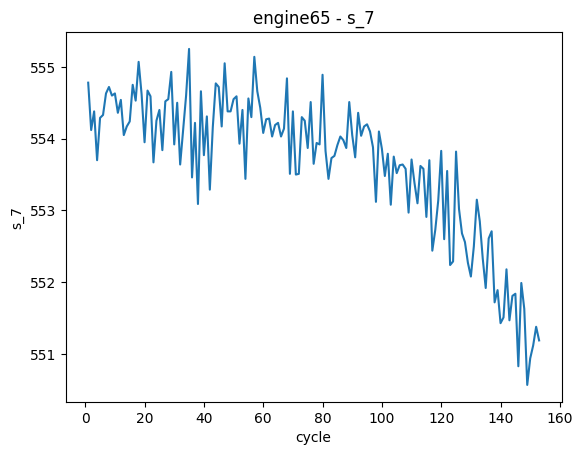

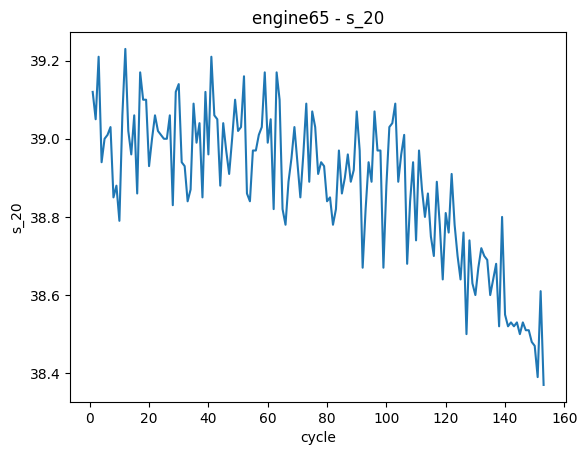

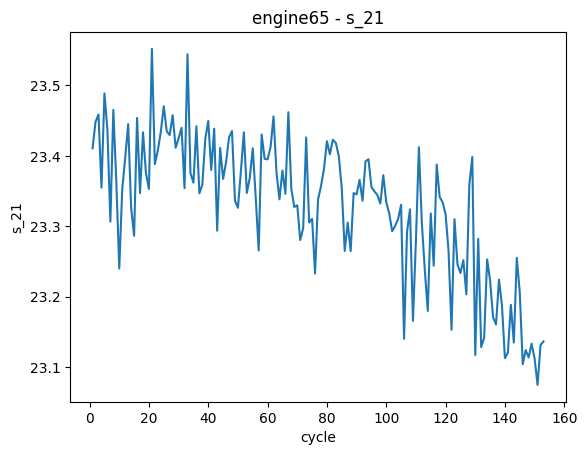

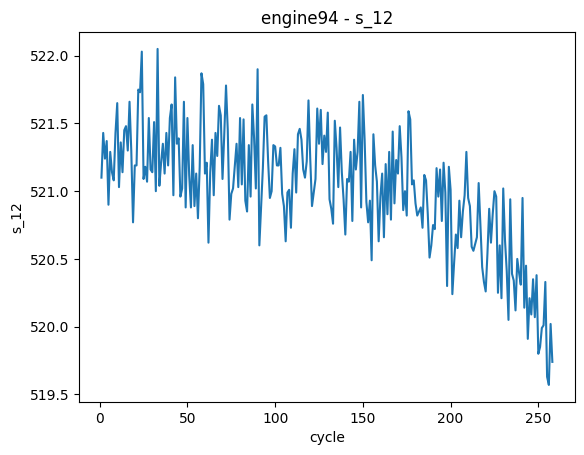

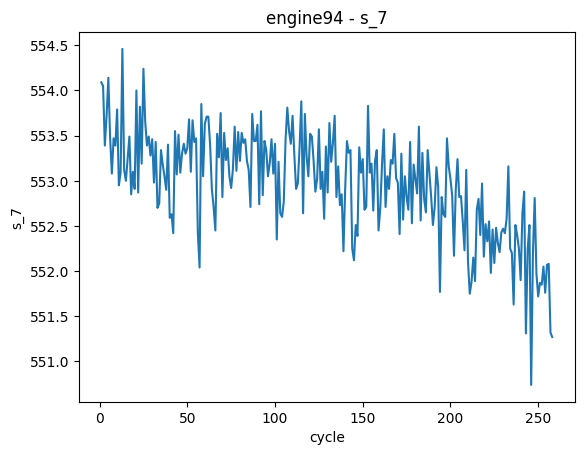

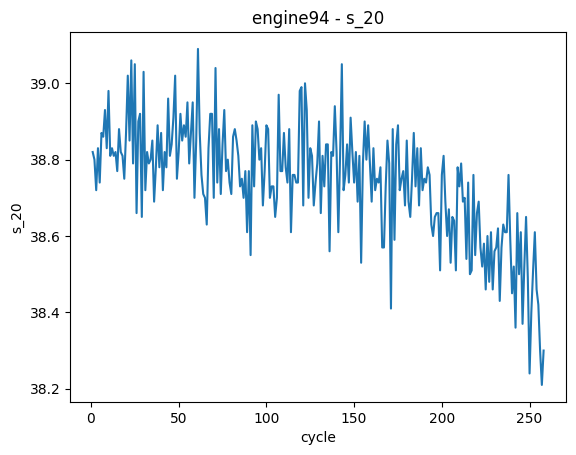

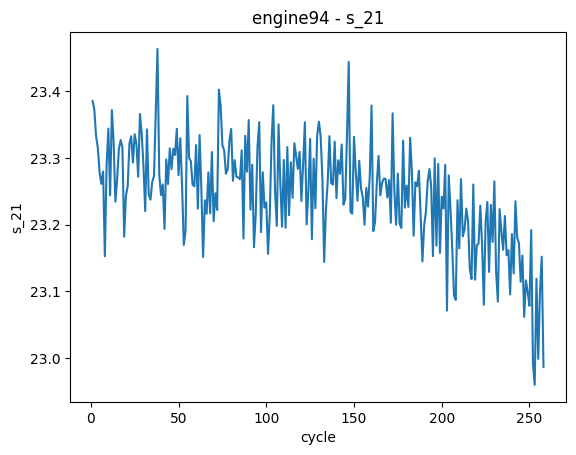

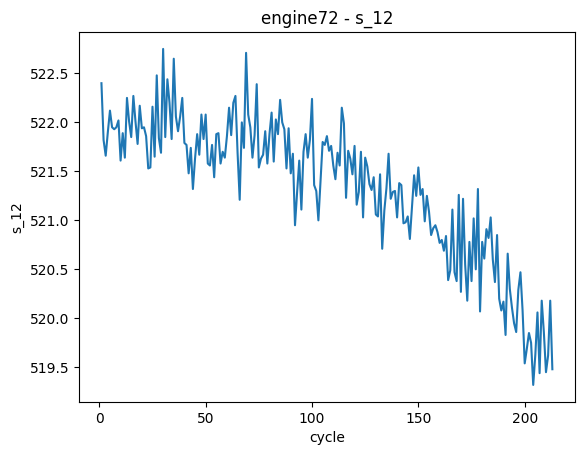

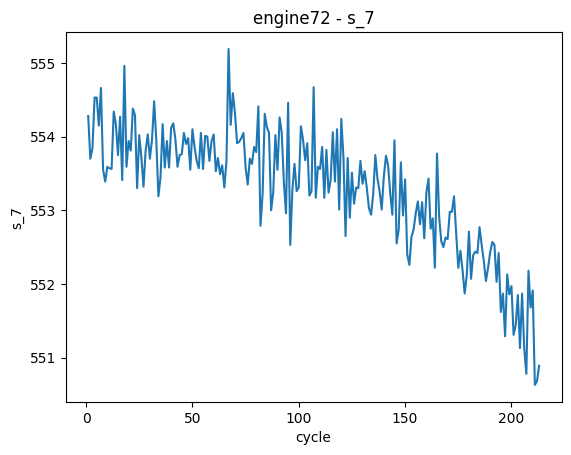

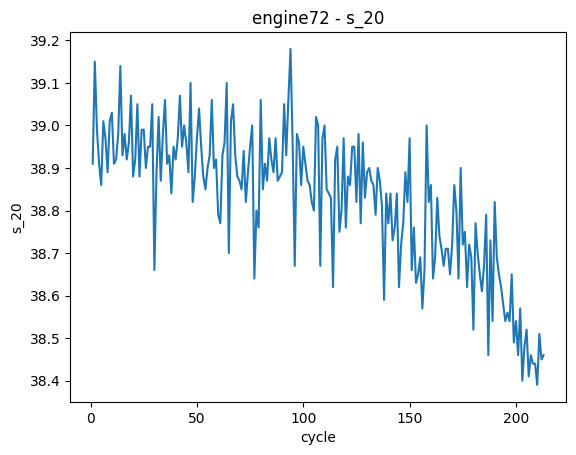

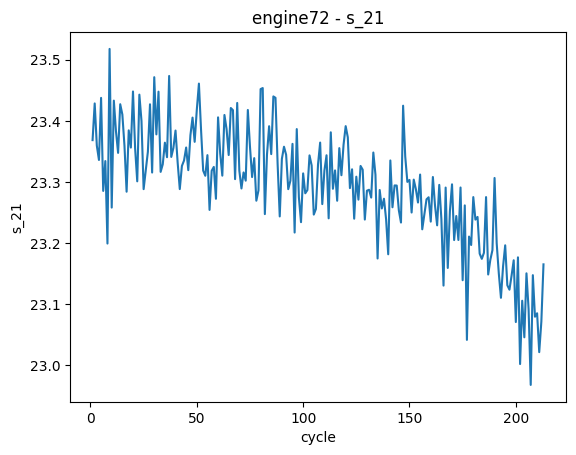

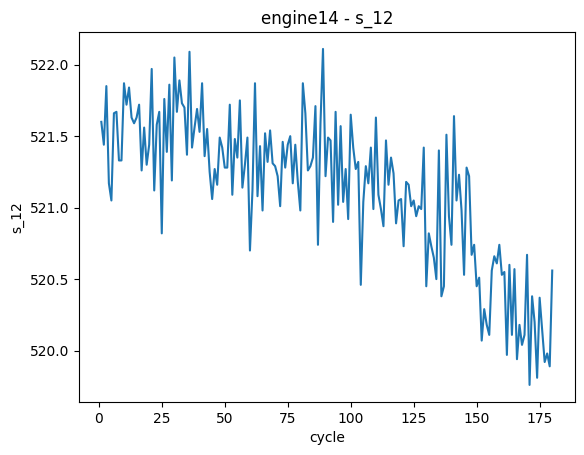

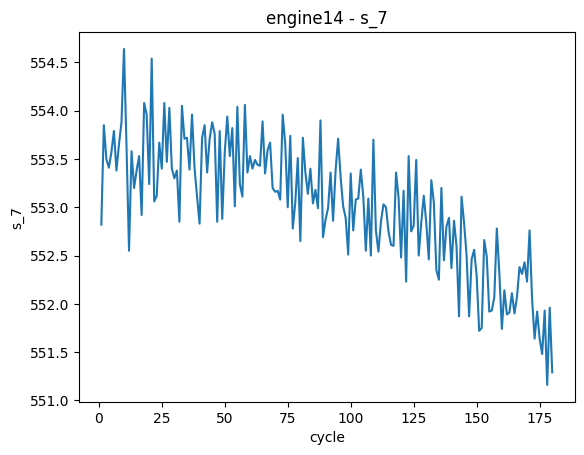

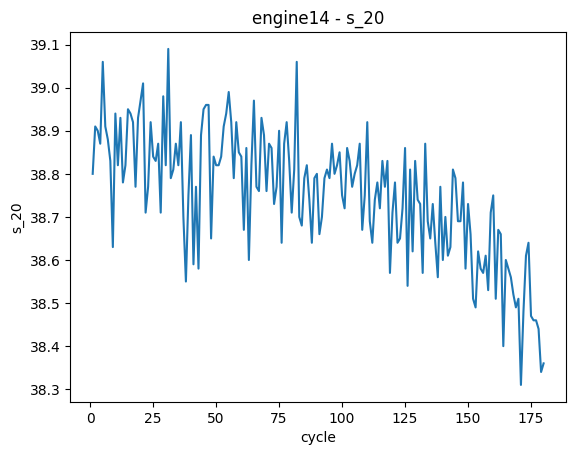

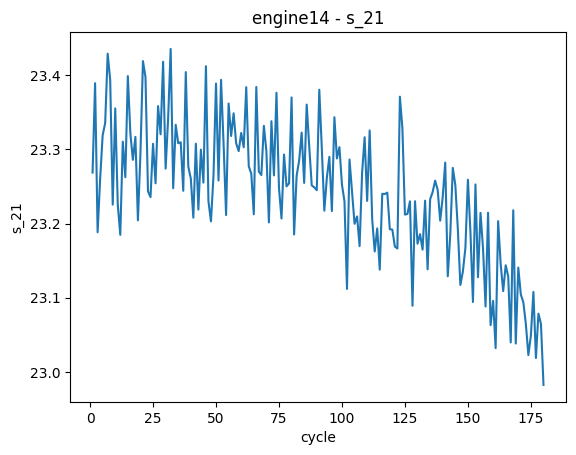

In [2]:
import random
%matplotlib inline
import matplotlib.pyplot as plt
df.columns = df.columns.str.strip()
engine_ids = df['unit'].unique()
sample_engines = [4,45,87,24,65,94,72,14]
sensor_cols = ['s_12','s_7','s_20','s_21']

for engine in sample_engines:
    engine_df = df[df['unit']== engine]
    for sensor in sensor_cols:
        plt.figure()
        plt.plot(engine_df['cycle'],engine_df[sensor])
        plt.title(f'engine{engine} - {sensor}')
        plt.xlabel('cycle')
        plt.ylabel(sensor)
        plt.show()

In [4]:
import pandas as pd


def add_rolling_features(df, sensor_cols, window_size=5, id_col="unit", time_col="cycle"):
   
    """
    Adds rolling mean and std for given sensor columns.
    
    Args:
        df: pandas DataFrame
        sensor_cols: list of sensor column names
        window_size: int
        
    Returns:
        df with new features
    """
    
    df = df.copy()
    
    df = df.sort_values(by=[id_col, time_col])
    
    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby(id_col)[col]
              .rolling(window=window_size, min_periods=1)
              .mean()
              .reset_index(level=0, drop=True)
        )
        
        df[f"{col}_roll_std"] = (
            df.groupby(id_col)[col]
              .rolling(window=window_size, min_periods=1)
              .std()
              .reset_index(level=0, drop=True)
              .fillna(0)
        )
    
    return df
sensor_cols =  ["s_12","s_7","s_14","s_20","s_21"]
df_features = add_rolling_features(df, sensor_cols, window_size=5)

In [5]:
df_features.groupby("unit").head(1)

,unit,cycle,op_1,op_2,op_3,s_1,s_2,s_3,s_4,s_5,...,s_12_roll_mean,s_12_roll_std,s_7_roll_mean,s_7_roll_std,s_14_roll_mean,s_14_roll_std,s_20_roll_mean,s_20_roll_std,s_21_roll_mean,s_21_roll_std
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,0.0,554.36,0.0,8138.62,0.0,39.06,0.0,23.4190,0.0
192,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,522.33,0.0,554.53,0.0,8137.72,0.0,38.94,0.0,23.4585,0.0
479,3,1,0.0008,0.0005,100.0,518.67,642.04,1584.20,1398.13,14.62,...,522.24,0.0,553.96,0.0,8138.40,0.0,38.96,0.0,23.3205,0.0
658,4,1,0.0025,0.0005,100.0,518.67,642.60,1585.40,1402.85,14.62,...,521.94,0.0,553.97,0.0,8131.50,0.0,39.04,0.0,23.3814,0.0
847,5,1,0.0031,0.0002,100.0,518.67,641.77,1583.59,1395.26,14.62,...,522.34,0.0,554.39,0.0,8152.22,0.0,38.98,0.0,23.4468,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19552,96,1,-0.0014,-0.0004,100.0,518.67,642.03,1579.12,1404.22,14.62,...,522.26,0.0,554.92,0.0,8133.36,0.0,38.82,0.0,23.4178,0.0
19888,97,1,-0.0038,0.0003,100.0,518.67,642.01,1581.83,1395.40,14.62,...,522.34,0.0,554.31,0.0,8130.81,0.0,38.94,0.0,23.3732,0.0
20090,98,1,0.0019,-0.0002,100.0,518.67,642.30,1580.93,1404.55,14.62,...,522.30,0.0,554.16,0.0,8150.69,0.0,39.01,0.0,23.4547,0.0
20246,99,1,0.0011,0.0005,100.0,518.67,641.69,1586.17,1391.14,14.62,...,522.65,0.0,554.09,0.0,8131.23,0.0,39.01,0.0,23.4007,0.0
